['.config', 'cnn_baseline_90_45.h5', 'archive.zip', 'brain_tumor_model_95.keras', 'sample_data']
total 327M
-rw-r--r-- 1 root root 158M Sep 15 12:49 archive.zip
-rw-r--r-- 1 root root  85M Sep 15 12:38 brain_tumor_model_95.keras
-rw-r--r-- 1 root root  85M Sep 15 12:47 cnn_baseline_90_45.h5
drwxr-xr-x 1 root root 4.0K Sep  4 13:25 sample_data
/content/archive.zip: Zip archive data, at least v4.5 to extract, compression method=deflate
True
Extraction completed successfully!
['Testing', 'Training']
['meningioma', 'pituitary', 'glioma', 'notumor']


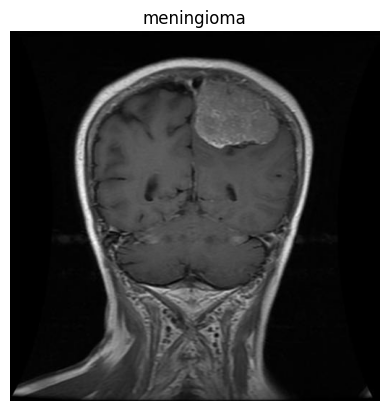

Images Loaded: 5600
Labels Loaded: 5600
X Shape: (5600, 128, 128, 3)
y Shape: (5600,)
Normalization Complete
0.0 1.0
Training Shape: (4480, 128, 128, 3)
Validation Shape: (1120, 128, 128, 3)


In [1]:
import os

print(os.listdir('/content'))

!ls -lh /content

!file /content/archive.zip

import zipfile

print(zipfile.is_zipfile('/content/archive.zip'))


import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Extraction completed successfully!")

import os

print(os.listdir('/content/dataset'))

import os

train_path = "/content/dataset/Training"

print(os.listdir(train_path))

import cv2
import matplotlib.pyplot as plt
import os

train_path = "/content/dataset/Training"

category = os.listdir(train_path)[0]

img_path = os.path.join(
    train_path,
    category,
    os.listdir(os.path.join(train_path, category))[0]
)

img = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(category)
plt.axis("off")
plt.show()

import os
import cv2
import numpy as np

IMG_SIZE = 128

data = []
labels = []

categories = ['notumor', 'meningioma', 'pituitary', 'glioma']

train_path = "/content/dataset/Training"

for category in categories:

    path = os.path.join(train_path, category)

    label = categories.index(category)

    for img in os.listdir(path):

        try:
            img_path = os.path.join(path, img)

            image = cv2.imread(img_path)

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            data.append(image)
            labels.append(label)

        except:
            pass

print("Images Loaded:", len(data))
print("Labels Loaded:", len(labels))



X = np.array(data)
y = np.array(labels)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X = X / 255.0

print("Normalization Complete")
print(X.min(), X.max())


from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))

model.summary()


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")


history = model.fit(
    X_train,
    y_train,
    epochs=70,
    validation_data=(X_val, y_val),
    batch_size=32
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Model Compiled Successfully
Epoch 1/70
140/140 ━━━━━━━━━━━━━━━━━━━━ 132s 923ms/step - accuracy: 0.6859 - loss: 0.7857 - val_accuracy: 0.8411 - val_loss: 0.4416
Epoch 2/70
140/140 ━━━━━━━━━━━━━━━━━━━━ 111s 796ms/step - accuracy: 0.8310 - loss: 0.4326 - val_accuracy: 0.8857 - val_loss: 0.3257
Epoch 3/70
140/140 ━━━━━━━━━━━━━━━━━━━━ 140s 786ms/step - accuracy: 0.8895 - loss: 0.2875 - val_accuracy: 0.9062 - val_loss: 0.2662
Epoch 4/70
140/140 ━━━━━━━━━━━━━━━━━━━━ 112s 801ms/step - accuracy: 0.9205 - loss: 0.2136 - val_accuracy: 0.8929 - val_loss: 0.3046
Epoch 5/70
140/140 ━━━━━━━━━━━━━━━━━━━━ 113s 807ms/step - accuracy: 0.9328 - loss: 0.1744 - val_accuracy: 0.9232 - val_loss: 0.2231
Epoch 6/70
140/140 ━━━━━━━━━━━━━━━━━━━━ 142s 807ms/step - accuracy: 0.9618 - loss: 0.1099 - val_accuracy: 0.9134 - val_loss: 0.2604
Epoch 7/70
140/140 ━━━━━━━━━━━━━━━━━━━━ 112s 803ms/step - accuracy: 0.9643 - loss: 0.1021 - val_accuracy: 0.9277 - val_loss: 0.2045
Epoch 8/70
140/140 ━━━━━━━━━━━━━━━━━━━━ 110s 787

Final Training Accuracy: 0.9986607432365417
Final Validation Accuracy: 0.9357143044471741


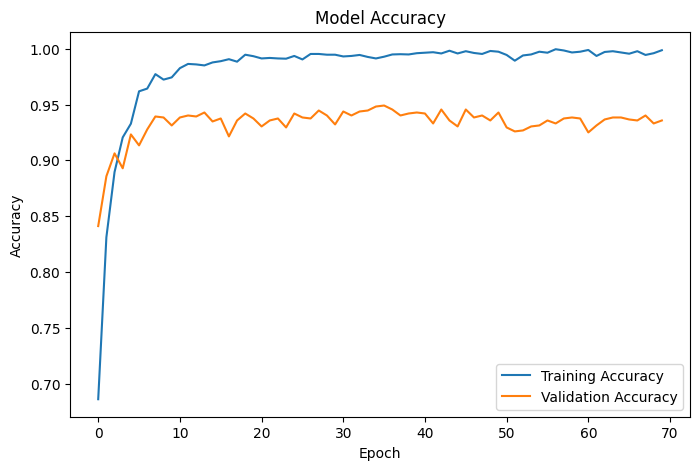

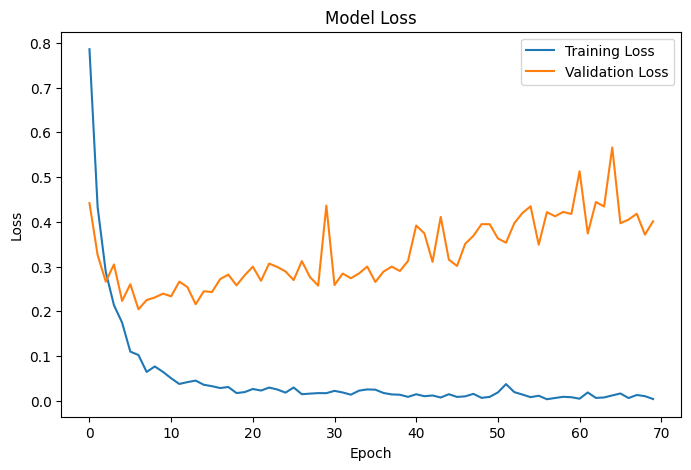

In [ ]:
print("Final Training Accuracy:",
      history.history['accuracy'][-1])

print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


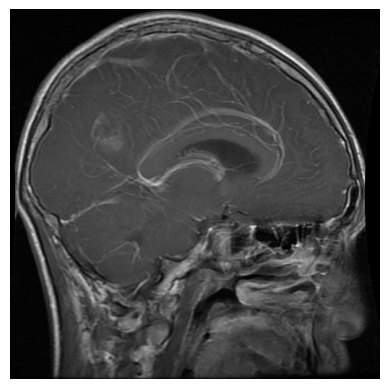

Predicted Class: glioma
Confidence: 99.456245


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

categories = ['notumor', 'meningioma', 'pituitary', 'glioma']

# Select a sample image
test_path = "/content/dataset/Testing/glioma"

img_name = os.listdir(test_path)[0]
img_path = os.path.join(test_path, img_name)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img, (128,128))
img_resized = img_resized / 255.0
img_resized = np.expand_dims(img_resized, axis=0)

prediction = model.predict(img_resized)

predicted_class = np.argmax(prediction)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

print("Predicted Class:", categories[predicted_class])
print("Confidence:", np.max(prediction)*100)


In [ ]:
model.save("cnn_baseline_90_45.h5")
model.save("brain_tumor_model_95.keras")

In [ ]:
from google.colab import files

files.download("brain_tumor_model_95.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import tensorflow as tf

model = tf.keras.models.load_model("brain_tumor_model_95.keras")

print("Model loaded successfully!")

Model loaded successfully!


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
################not needed
from sklearn.metrics import classification_report

y_pred = model.predict(X_val)
y_pred_classes = y_pred.argmax(axis=1)

print(classification_report(y_val, y_pred_classes))

from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_val, y_pred_classes)

cm_df = pd.DataFrame(
    cm,
    index=['notumor','meningioma','pituitary','glioma'],
    columns=['notumor','meningioma','pituitary','glioma']
)

print(cm_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       280
           1       0.86      0.90      0.88       280
           2       0.96      0.99      0.97       280
           3       0.95      0.89      0.92       280

    accuracy                           0.94      1120
   macro avg       0.94      0.94      0.94      1120
weighted avg       0.94      0.94      0.94      1120

            notumor  meningioma  pituitary  glioma
notumor         268          11          1       0
meningioma        7         253          8      12
pituitary         0           2        278       0
glioma            0          27          4     249


In [ ]:
import os
import cv2
import numpy as np

categories = ['notumor', 'meningioma', 'pituitary', 'glioma']

img_name = os.listdir("/content/dataset/Testing/glioma")[0]
img_path = os.path.join("/content/dataset/Testing/glioma", img_name)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (128,128))

pred = model.predict(
    np.expand_dims(img/255.0, axis=0),
    verbose=0
)

print("Raw Prediction:", pred)
print("Class:", categories[np.argmax(pred)])
print("Confidence:", np.max(pred)*100)


for i in range(5):
    img_name = os.listdir("/content/dataset/Testing/glioma")[i]

    img = cv2.imread(
        os.path.join("/content/dataset/Testing/glioma", img_name)
    )

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128,128))

    pred = model.predict(
        np.expand_dims(img/255.0, axis=0),
        verbose=0
    )

    print(
        f"Image {i+1}:",
        categories[np.argmax(pred)],
        f"({np.max(pred)*100:.2f}%)"
    )

Raw Prediction: [[1.0684499e-05 1.3561268e-08 5.4269033e-03 9.9456245e-01]]
Class: glioma
Confidence: 99.456245
Image 1: glioma (99.46%)
Image 2: glioma (100.00%)
Image 3: meningioma (99.99%)
Image 4: meningioma (90.56%)
Image 5: glioma (100.00%)


In [ ]:
import random
import os
import cv2
import numpy as np

folder = "/content/dataset/Testing/glioma"

files = random.sample(os.listdir(folder), 20)

correct = 0

for f in files:
    img_path = os.path.join(folder, f)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128,128))

    pred = model.predict(
        np.expand_dims(img/255.0, axis=0),
        verbose=0
    )

    pred_class = categories[np.argmax(pred)]

    if pred_class == "glioma":
        correct += 1

    print(f, "->", pred_class)

print("\nAccuracy on sample:", correct, "/ 20")

Te-gl_386.jpg -> glioma
Te-gl_333.jpg -> glioma
Te-gl_234.jpg -> glioma
Te-gl_342.jpg -> glioma
Te-gl_291.jpg -> glioma
Te-gl_375.jpg -> glioma
Te-gl_309.jpg -> glioma
Te-gl_305.jpg -> meningioma
Te-gl_68.jpg -> meningioma
Te-gl_44.jpg -> glioma
Te-gl_371.jpg -> meningioma
Te-gl_385.jpg -> glioma
Te-gl_14.jpg -> meningioma
Te-gl_247.jpg -> meningioma
Te-gl_203.jpg -> glioma
Te-gl_296.jpg -> glioma
Te-gl_195.jpg -> glioma
Te-gl_56.jpg -> meningioma
Te-gl_264.jpg -> meningioma
Te-gl_57.jpg -> glioma

Accuracy on sample: 13 / 20


In [7]:
#lime
!pip install lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np
import cv2
from tensorflow.keras.models import load_model

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=3adae599e5bd53ba1606c7ede6e0de756df95fd947dcb556e5236c11fe3104ea
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [6]:
import tensorflow as tf

model = tf.keras.models.load_model("cnn_baseline_90_45.h5")

print("Model loaded successfully!")

Model loaded successfully!


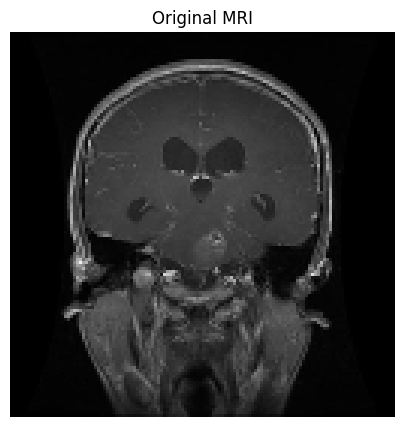

  0%|          | 0/1000 [00:00<?, ?it/s]

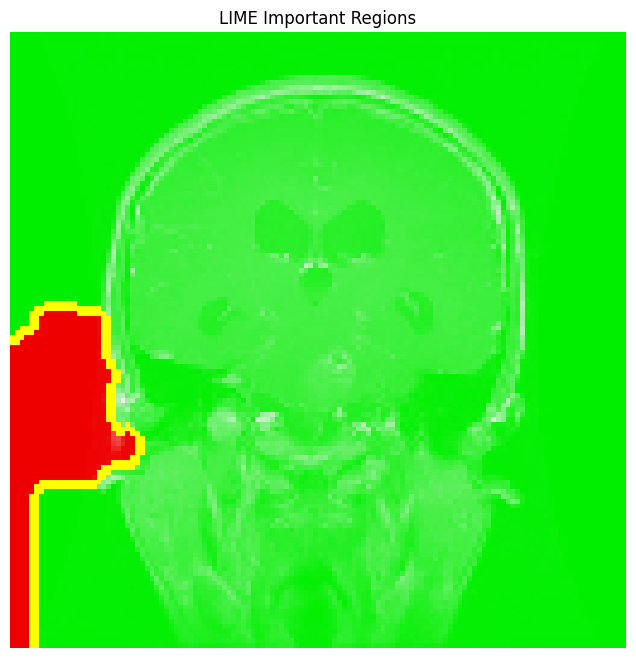

Prediction: pituitary
Confidence: 100.00%

Class Probabilities:
glioma: 0.00%
meningioma: 0.00%
notumor: 0.00%
pituitary: 100.00%


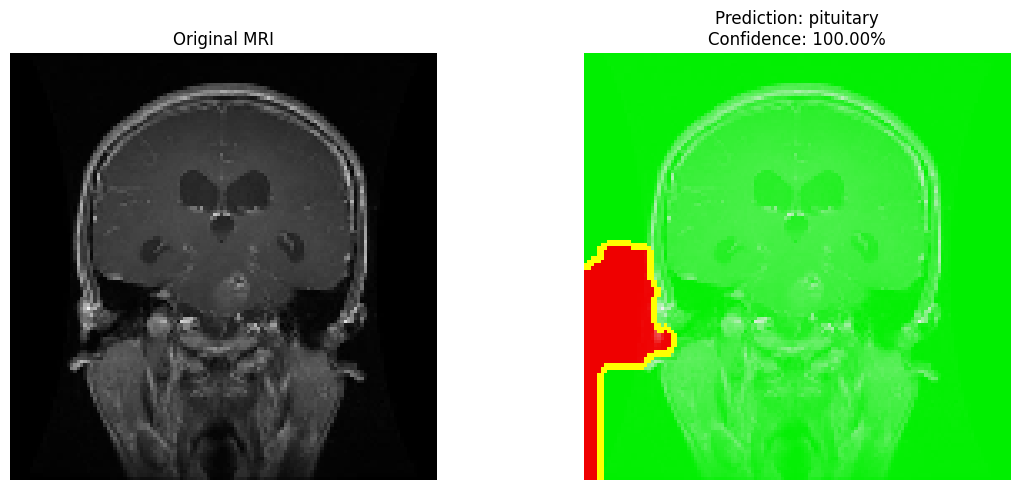

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from lime import lime_image
from skimage.segmentation import mark_boundaries

# -----------------------------
# Prediction function for LIME
# -----------------------------
def predict_fn(images):
    images = np.array(images)
    images = images.astype("float32") / 255.0
    return model.predict(images, verbose=0)

# -----------------------------
# Load image
# -----------------------------
img_path = "/content/dataset/Testing/glioma/Te-gl_95.jpg"

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_resized = cv2.resize(image, (128, 128))

# Display original image
plt.figure(figsize=(5,5))
plt.imshow(image_resized)
plt.title("Original MRI")
plt.axis("off")
plt.show()

# -----------------------------
# Generate LIME explanation
# -----------------------------
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image_resized,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# -----------------------------
# Get important regions
# -----------------------------
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=False,
    num_features=20,
    hide_rest=False
)

# Display LIME result
plt.figure(figsize=(8,8))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Important Regions")
plt.axis("off")
plt.show()

# -----------------------------
# Model Prediction
# -----------------------------
prediction = model.predict(
    np.expand_dims(image_resized / 255.0, axis=0),
    verbose=0
)

# IMPORTANT:
# Replace this list with the exact order
# used during training.
categories = [
    'glioma',
    'meningioma',
    'notumor',
    'pituitary'
]

pred_index = np.argmax(prediction)
pred_class = categories[pred_index]
confidence = np.max(prediction) * 100

print(f"Prediction: {pred_class}")
print(f"Confidence: {confidence:.2f}%")

# Print all class probabilities
print("\nClass Probabilities:")
for cls, prob in zip(categories, prediction[0]):
    print(f"{cls}: {prob*100:.2f}%")

# -----------------------------
# Side-by-side visualization
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(image_resized)
ax[0].set_title("Original MRI")
ax[0].axis("off")

ax[1].imshow(mark_boundaries(temp / 255.0, mask))
ax[1].set_title(
    f"Prediction: {pred_class}\nConfidence: {confidence:.2f}%"
)
ax[1].axis("off")

plt.tight_layout()
plt.show()






In [ ]:
from tensorflow.keras.models import load_model

model = load_model("cnn_baseline_90_45.h5")

categories = ['notumor', 'meningioma', 'pituitary', 'glioma']

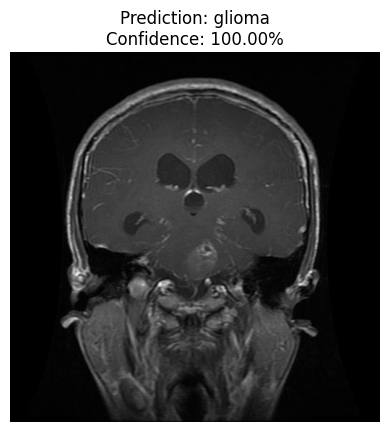

Predicted Class: glioma
Confidence: 100.0


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/dataset/Testing/glioma/Te-gl_95.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img, (128,128))

prediction = model.predict(
    np.expand_dims(img_resized/255.0, axis=0),
    verbose=0
)

pred_class = categories[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {pred_class}\nConfidence: {confidence:.2f}%")
plt.show()

print("Predicted Class:", pred_class)
print("Confidence:", confidence)

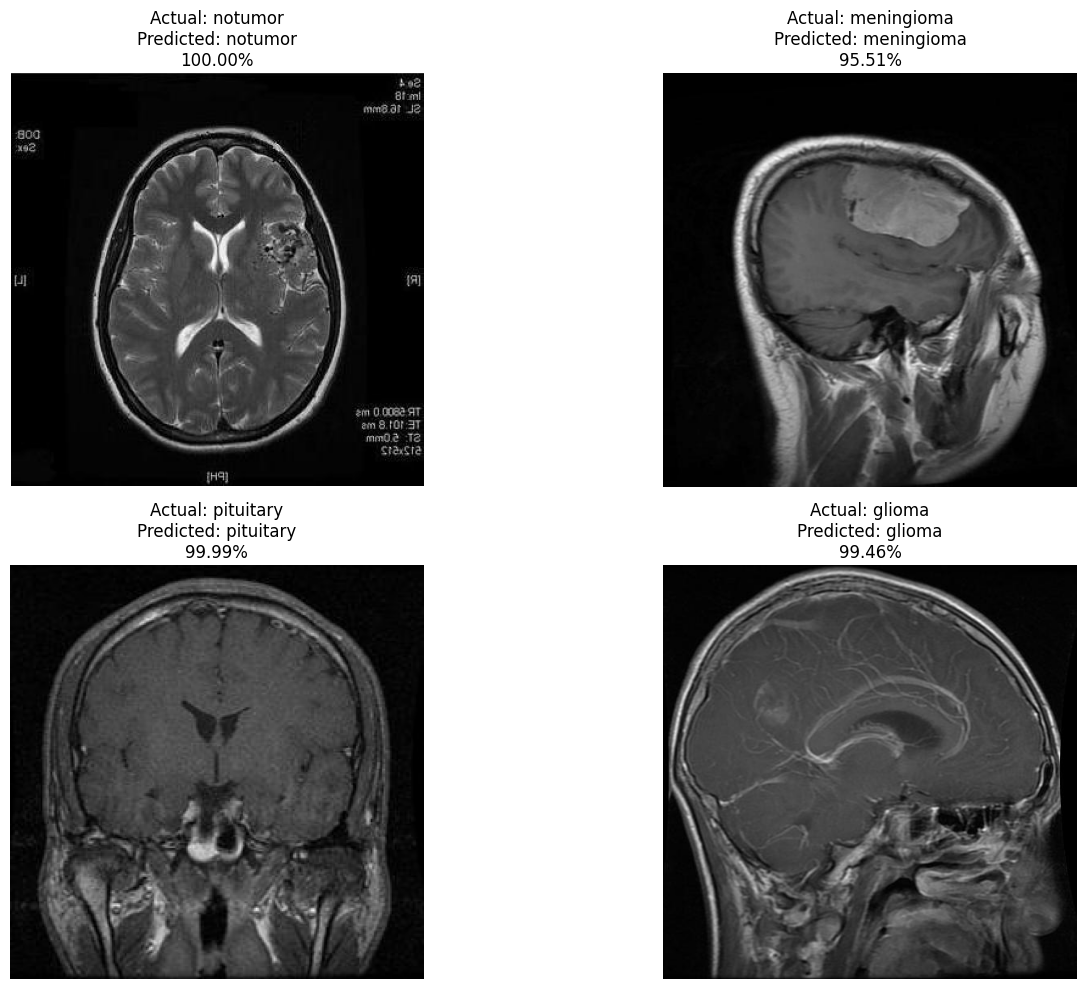

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

classes = ['notumor', 'meningioma', 'pituitary', 'glioma']

plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):

    img_name = os.listdir(f"/content/dataset/Testing/{cls}")[0]

    img_path = os.path.join(
        f"/content/dataset/Testing/{cls}",
        img_name
    )

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, (128,128))

    pred = model.predict(
        np.expand_dims(img_resized/255.0, axis=0),
        verbose=0
    )

    pred_class = categories[np.argmax(pred)]
    confidence = np.max(pred)*100

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Actual: {cls}\nPredicted: {pred_class}\n{confidence:.2f}%"
    )

plt.tight_layout()
plt.show()

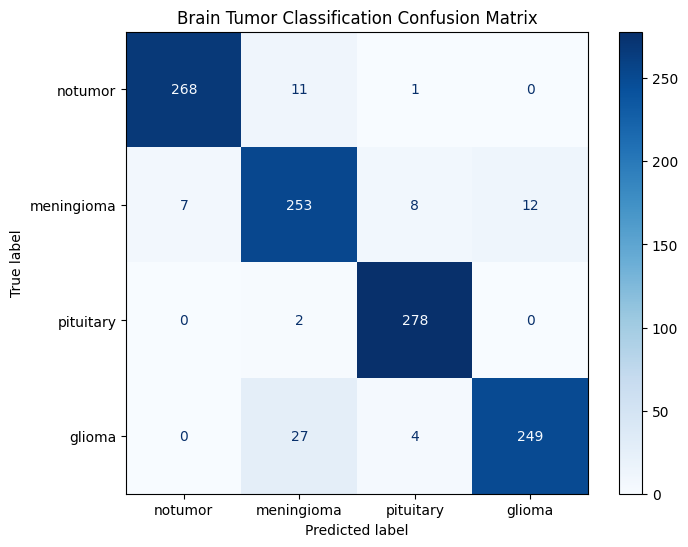


Classification Report:

              precision    recall  f1-score   support

     notumor       0.97      0.96      0.97       280
  meningioma       0.86      0.90      0.88       280
   pituitary       0.96      0.99      0.97       280
      glioma       0.95      0.89      0.92       280

    accuracy                           0.94      1120
   macro avg       0.94      0.94      0.94      1120
weighted avg       0.94      0.94      0.94      1120



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_val, verbose=0)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true_classes = y_val

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=categories
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues")
plt.title("Brain Tumor Classification Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(
    classification_report(
        y_true_classes,
        y_pred_classes,
        target_names=categories
    )
)

In [ ]:
import random

folder = "/content/dataset/Testing/glioma"

images = random.sample(os.listdir(folder), 10)

for img_name in images:

    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, (128,128))

    pred = model.predict(
        np.expand_dims(img_resized/255.0, axis=0),
        verbose=0
    )

    print(
        img_name,
        "->",
        categories[np.argmax(pred)],
        f"({np.max(pred)*100:.2f}%)"
    )

Te-gl_309.jpg -> glioma (77.27%)
Te-gl_45.jpg -> glioma (100.00%)
Te-gl_254.jpg -> glioma (100.00%)
Te-gl_224.jpg -> meningioma (88.11%)
Te-gl_336.jpg -> meningioma (99.53%)
Te-gl_264.jpg -> meningioma (100.00%)
Te-gl_39.jpg -> meningioma (100.00%)
Te-gl_398.jpg -> glioma (100.00%)
Te-gl_395.jpg -> glioma (99.99%)
Te-gl_215.jpg -> meningioma (70.72%)


In [ ]:
##############################
